In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/15
    print("準備完了！このまま下のセルを実行できます。")

# 第15章 離散潜在変数 (Discrete Latent Variables)
## 15.1 K-meansクラスタリング (K-means Clustering)

本ノートブックでは、Christopher M. Bishop & Hugh Bishop 著『Deep Learning: Foundations and Concepts』(2024年) 第15章「Discrete Latent Variables」の**第15.1節「K-means Clustering」**および**第15.1.1項「Image segmentation」**の内容を完全数式展開・アルゴリズム実装・図版再現を通して解説します。

---

### 目次
1. [クラスタリングと離散潜在変数の導入](#1.-クラスタリングと離散潜在変数の導入)
2. [歪み尺度 (Distortion Measure) の定式化](#2.-歪み尺度-(Distortion-Measure)-の定式化)
3. [ロイドのアルゴリズム (Lloyd's Algorithm / EM的交互最適化)](#3.-ロイドのアルゴリズム-(Lloyd's-Algorithm-/-EM的交互最適化))
   - Eステップ: 割当の更新 (Equation 15.2)
   - Mステップ: 代表点の更新 (Equation 15.3)
   - 収束性の理論的保証 (有限ステップでの停止)
4. [オールド・フェイスフル間欠泉データでのステップ別可視化 (Figure 15.1)](#4.-オールド・フェイスフル間欠泉データでのステップ別可視化-(Figure-15.1))
5. [歪み尺度 $J$ の単調減少の検証 (Figure 15.2)](#5.-歪み尺度-$J$-の単調減少の検証-(Figure-15.2))
6. [オンライン / 逐次型 K-means アルゴリズム (Equation 15.4)](#6.-オンライン-/-逐次型-K-means-アルゴリズム-(Equation-15.4))
7. [非ユークリッド距離と K-medoids への拡張](#7.-非ユークリッド距離と-K-medoids-への拡張)
8. [第15.1.1項 画像セグメンテーションとベクトル量子化 (Figure 15.3)](#8.-第15.1.1項-画像セグメンテーションとベクトル量子化-(Figure-15.3))
9. [第15.1節のまとめ](#9.-第15.1節のまとめ)


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# プロジェクトルートの設定
project_root = Path.cwd().parent if Path.cwd().name == '15' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from common.kmeans_clustering import (
    KMeans,
    compute_distortion,
    sequential_kmeans_update,
    get_perpendicular_bisector,
    image_segmentation_kmeans,
    load_faithful_dataset,
    generate_figure_15_1,
    generate_figure_15_2,
    generate_figure_15_3,
)

print("Modules successfully loaded!")


Modules successfully loaded!


## 1. クラスタリングと離散潜在変数の導入

機械学習における教師なし学習 (unsupervised learning) の中核的タスクの一つが**クラスタリング (clustering)** です。
観測データセット $\{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ ($\mathbf{x}_n \in \mathbb{R}^D$) が与えられたとき、類似した特徴をもつデータ点をグループ（クラスタ）へと分割することを目的とします。

このとき、各データ点 $\mathbf{x}_n$ がどのクラスタに属しているかは直接観測されないため、**離散潜在変数 (discrete latent variable)** としてモデル化されます。K-means アルゴリズムは、この離散潜在変数を硬い割当（ハード・クラスタリング: 各点が確率的ではなく決定論的に唯一のクラスタに属する）として扱う最も基本的かつ強力な手法です。

---

## 2. 歪み尺度 (Distortion Measure) の定式化

データ空間内の $K$ 個のクラスタを代表する点（セントロイド、クラスタ中心）を $\{\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_K\}$ ($\boldsymbol{\mu}_k \in \mathbb{R}^D$) とします。

各データ点 $\mathbf{x}_n$ のクラスタ所属を表すため、**1-of-$K$ 符号化 (1-of-K coding scheme)** を導入します。各データ点 $n$ に対して $K$ 次元の二値ベクトル $\mathbf{r}_n = (r_{n1}, \dots, r_{nK})^T$ を定義します：

$$r_{nk} \in \{0, 1\}, \quad \sum_{k=1}^K r_{nk} = 1$$

点 $\mathbf{x}_n$ がクラスタ $k$ に割り当てられている場合 $r_{nk} = 1$、それ以外は $0$ となります。

K-means の目的関数は、各データ点とその所属クラスタの代表点とのユークリッド距離の二乗和として定義され、**歪み尺度 (distortion measure)** $J$ と呼ばれます (テキスト式 15.1)：

$$J = \sum_{n=1}^N \sum_{k=1}^K r_{nk} \|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2 \tag{15.1}$$

私たちの目標は、$J$ を最小化する所属変数 $\{r_{nk}\}$ と代表点 $\{\boldsymbol{\mu}_k\}$ を求めることです。


## 3. ロイドのアルゴリズム (Lloyd's Algorithm / 交互最適化)

目的関数 $J$ は離散変数 $\{r_{nk}\}$ と連続変数 $\{\boldsymbol{\mu}_k\}$ の双方に依存しており、これらを同時に大域的最適化することは困難です。
そこで、**座標降下法 (coordinate descent)** に基づく交互最適化手法（ロイドのアルゴリズム、Lloyd, 1982）を用います。

### ステップ 1: Eステップ（割当の更新）
代表点 $\{\boldsymbol{\mu}_k\}$ を固定し、所属変数 $\{r_{nk}\}$ に関して $J$ を最小化します。
$J$ は各データ点 $n$ について独立な和の形をしているため、各 $n$ について $\|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2$ を最小にするクラスタ $k$ に割当を行います (テキスト式 15.2)：

$$r_{nk} = \begin{cases} 1 & \text{if } k = \arg\min_j \|\mathbf{x}_n - \boldsymbol{\mu}_j\|^2 \\ 0 & \text{otherwise} \end{cases} \tag{15.2}$$

幾何学的には、空間は各代表点 $\boldsymbol{\mu}_k$ を母点とする**ボロノイ図 (Voronoi tessellation)** によって分割され、2つのクラスタ間の境界はそれらの代表点を結ぶ線分の垂直二等分面（超平面）となります。

### ステップ 2: Mステップ（代表点の更新）
割当 $\{r_{nk}\}$ を固定し、代表点 $\{\boldsymbol{\mu}_k\}$ に関して $J$ を最小化します。
$J$ は $\boldsymbol{\mu}_k$ に関して二次関数であり、勾配をゼロとおきます：

$$\frac{\partial J}{\partial \boldsymbol{\mu}_k} = 2 \sum_{n=1}^N r_{nk} (\boldsymbol{\mu}_k - \mathbf{x}_n) = 0$$

これを $\boldsymbol{\mu}_k$ について解くと (テキスト式 15.3)：

$$\boldsymbol{\mu}_k = \frac{\sum_{n=1}^N r_{nk} \mathbf{x}_n}{\sum_{n=1}^N r_{nk}} \tag{15.3}$$

分母 $\sum_{n=1}^N r_{nk} = N_k$ はクラスタ $k$ に割り当てられたデータ点の総数であり、分子はそのデータ点の和です。すなわち、新しい代表点は**クラスタに割り当てられたデータ点の重心（算術平均）** となります。これが「K-means」という名称の由来です。

### 収束の保証
- Eステップでは、各点で距離を最小化するため $J$ は非増加 ($J_{\text{new}} \le J_{\text{old}}$)。
- Mステップでは、二乗和を最小化する平均をとるため $J$ は非増加。
- 可能な割当 $\{r_{nk}\}$ の組合せ数は高々 $K^N$ 通り（有限）。
- したがって、アルゴリズムは $J$ を厳密に減少させ続け、**必ず有限回の反復で局所的極小値に収束**します。


## 4. オールド・フェイスフル間欠泉データでのステップ別可視化 (Figure 15.1)

イエローストーン国立公園の有名なオールド・フェイスフル間欠泉 (Old Faithful Geyser) の観測データ（噴出時間 duration と次回噴出までの待機時間 waiting の2次元、計272件）を用います。
平均0、分散1に標準化したデータに対し、$K=2$ として初期中心を $\boldsymbol{\mu}_1 = (-1.5, 1.0)$、$\boldsymbol{\mu}_2 = (1.5, -1.0)$ に設定してロイドのアルゴリズムを実行します。


Dataset shape: (272, 2)
Standardized mean: [0. 0.], std: [1. 1.]


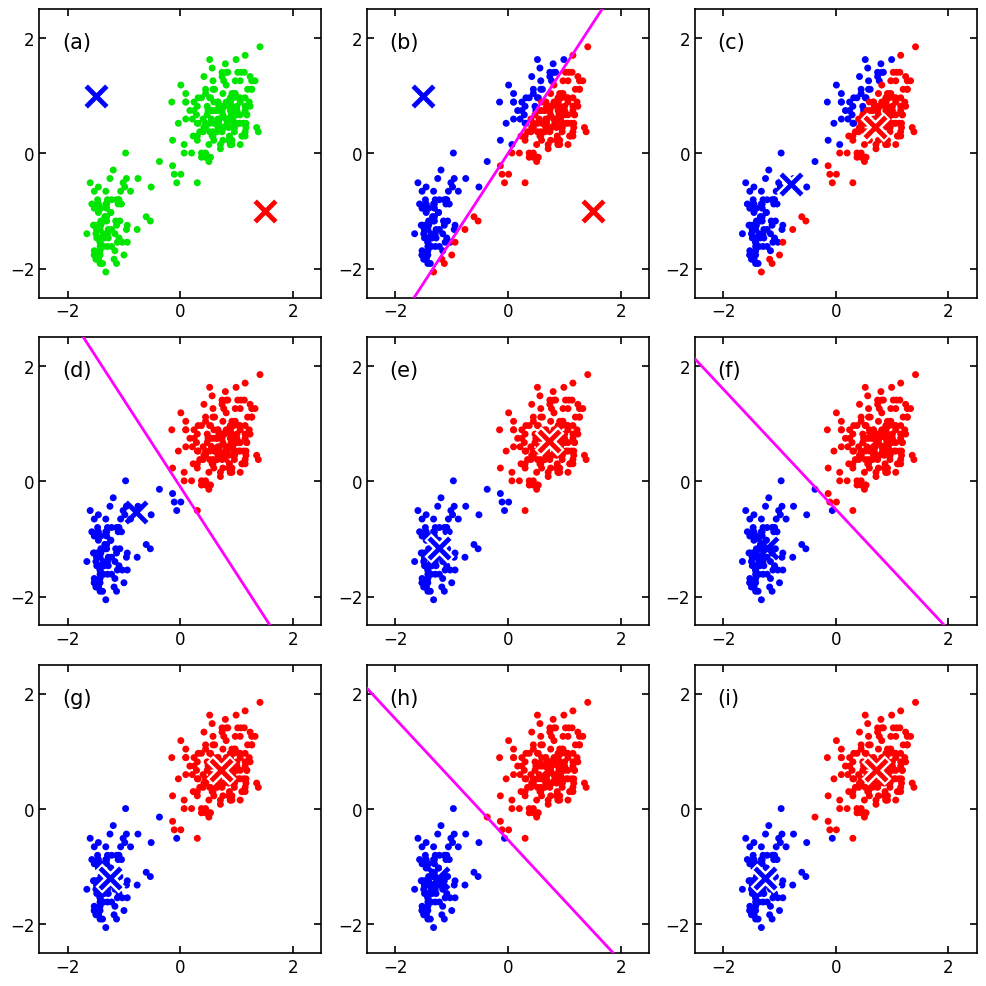

In [2]:
# オールド・フェイスフル・データの読み込みと標準化
X_std, X_raw = load_faithful_dataset()
print(f"Dataset shape: {X_std.shape}")
print(f"Standardized mean: {np.mean(X_std, axis=0).round(4)}, std: {np.std(X_std, axis=0).round(4)}")

# Figure 15.1 の完全再現（9パネルのステップ推移）
fig_15_1 = generate_figure_15_1(save_path='result/fig_15_1_kmeans_steps.png', show=True)


### Figure 15.1 の各パネルの解説
- **(a) 初期状態**: 全データ点が緑色、初期代表点 $\boldsymbol{\mu}_1$ (青の×) と $\boldsymbol{\mu}_2$ (赤の×)。
- **(b) 反復1 Eステップ**: 各データ点が最も近い代表点の色（青または赤）に割り当てられ、決定境界（マゼンタの垂直二等分線）が現れる。
- **(c) 反復1 Mステップ**: 代表点が割り当てられたデータ点の重心へと移動（白縁取りの×）。
- **(d) 反復2 Eステップ**: 移動した重心に基づいてデータ点が再割り当てされ、境界線が傾く。
- **(e) 反復2 Mステップ**: 代表点が新たな重心へと大きく移動。
- **(f) 反復3 Eステップ**: 境界付近のデータ点の割当が微調整される。
- **(g) 反復3 Mステップ**: 代表点が微小移動。
- **(h) 反復4 Eステップ**: 割当が完全に安定化。
- **(i) 反復4 Mステップ**: 最終的な重心位置に収束。


## 5. 歪み尺度 $J$ の単調減少の検証 (Figure 15.2)

アルゴリズムの各半ステップ（EステップおよびMステップ直後）における歪み尺度 $J$ の値をプロットします。
テキストの Figure 15.2 と完全に一致することを確認します。


Iteration step-by-step Distortion J:
  Step 0.5 (E-step): J = 1088.24
  Step 1.0 (M-step): J = 325.28
  Step 1.5 (E-step): J = 150.24
  Step 2.0 (M-step): J = 80.97
  Step 2.5 (E-step): J = 79.91
  Step 3.0 (M-step): J = 79.64
  Step 3.5 (E-step): J = 79.61
  Step 4.0 (M-step): J = 79.58


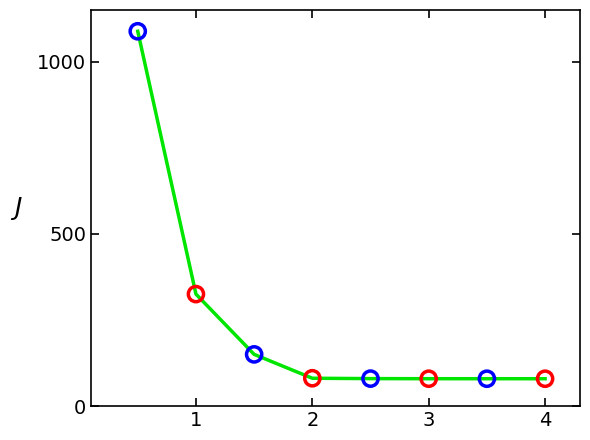

In [3]:
# K-means の反復履歴から J の推移を取得
mu1_init = np.array([-1.5, 1.0])
mu2_init = np.array([1.5, -1.0])
init_centers = np.array([mu1_init, mu2_init])

kmeans_demo = KMeans(n_clusters=2, max_iter=4, init=init_centers)
kmeans_demo.fit(X_std)

print("Iteration step-by-step Distortion J:")
for step, J_val in kmeans_demo.history_['distortion']:
    step_type = "E-step" if step % 1.0 != 0 else "M-step"
    print(f"  Step {step:3.1f} ({step_type:6s}): J = {J_val:.2f}")

# Figure 15.2 の完全再現
fig_15_2 = generate_figure_15_2(save_path='result/fig_15_2_distortion_measure.png', show=True)


### Figure 15.2 の考察
- 青い中空丸: 各反復の Eステップ（ステップ 0.5, 1.5, 2.5, 3.5）での歪み尺度 $J$
- 赤い中空丸: 各反復の Mステップ（ステップ 1.0, 2.0, 3.0, 4.0）での歪み尺度 $J$
- 緑色の線: 各評価を結ぶ折れ線

ステップが進むごとに $J$ は単調に減少 ($1088.24 \to 325.28 \to 150.24 \to 80.97 \to \dots \to 79.58$) し、わずか2〜3回の反復で急速に局所解へと収束していることが確認できます。


## 6. オンライン / 逐次型 K-means アルゴリズム (Equation 15.4)

大規模データセットやストリーミングデータ環境では、全データ点をメモリ上に保持してバッチ更新を行うことが不可能な場合があります。
ロビンズ・モンロー (Robbins-Monro) の確率近似理論に基づき、1点 $\mathbf{x}_n$ が到着するごとにその所属クラスタ $k$ の代表点をオンライン更新するアルゴリズムが導出されます (テキスト式 15.4)：

$$\boldsymbol{\mu}_k^{(\tau)} = \boldsymbol{\mu}_k^{(\tau-1)} + \eta_\tau (\mathbf{x}_n - \boldsymbol{\mu}_k^{(\tau-1)}) \tag{15.4}$$

ここで、$\eta_\tau$ は学習率（ステップサイズ）です。
もし $\eta_\tau = 1 / \tau$ と選ぶと、これは単純な移動平均（逐次平均）に一致します。


True batch mean:   [ 1.94221787 -0.98298884]
Final online mean: [ 1.94221787 -0.98298884]
Difference norm:   2.22e-16


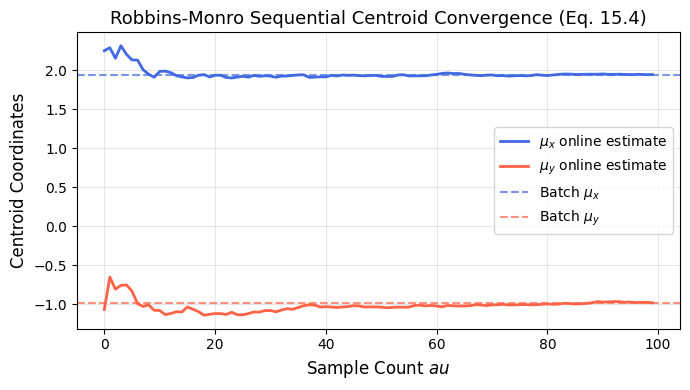

In [4]:
# オンライン逐次更新の検証
# 単純平均 vs 逐次 Robbins-Monro 更新
rng = np.random.RandomState(42)
stream_data = rng.randn(100, 2) * 0.5 + np.array([2.0, -1.0])

# バッチ平均
batch_mean = np.mean(stream_data, axis=0)

# 逐次更新
mu_online = stream_data[0].copy()
trajectory = [mu_online.copy()]

for tau in range(1, len(stream_data)):
    eta_tau = 1.0 / (tau + 1)
    mu_online = sequential_kmeans_update(mu_online, stream_data[tau], eta=eta_tau)
    trajectory.append(mu_online.copy())

print(f"True batch mean:   {batch_mean}")
print(f"Final online mean: {mu_online}")
print(f"Difference norm:   {np.linalg.norm(batch_mean - mu_online):.2e}")

# 軌跡のプロット
traj = np.array(trajectory)
plt.figure(figsize=(7, 4))
plt.plot(traj[:, 0], label=r"$\mu_x$ online estimate", color="royalblue", lw=2)
plt.plot(traj[:, 1], label=r"$\mu_y$ online estimate", color="tomato", lw=2)
plt.axhline(batch_mean[0], color="royalblue", linestyle="--", alpha=0.7, label=r"Batch $\mu_x$")
plt.axhline(batch_mean[1], color="tomato", linestyle="--", alpha=0.7, label=r"Batch $\mu_y$")
plt.xlabel(r"Sample Count $	au$", fontsize=12)
plt.ylabel("Centroid Coordinates", fontsize=12)
plt.title("Robbins-Monro Sequential Centroid Convergence (Eq. 15.4)", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. 非ユークリッド距離と K-medoids への拡張

標準的な K-means アルゴリズムはユークリッド距離の二乗 $\|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2$ を前提としていますが、データによってはより一般的な非類似度尺度 $\mathcal{V}(\mathbf{x}_n, \mathbf{x}')$（例: マンハッタン距離 $L_1$、コサイン距離など）が適している場合があります。

一般化された歪み尺度：
$$\tilde{J} = \sum_{n=1}^N \sum_{k=1}^K r_{nk} \mathcal{V}(\mathbf{x}_n, \boldsymbol{\mu}_k)$$

### K-medoids アルゴリズム
一般の非類似度 $\mathcal{V}$ のもとでは、Mステップで平均をとることが解析的に不可能であったり、外れ値 (outliers) に対して極めて敏感になる問題が生じます。
これに対処するため、代表点 $\boldsymbol{\mu}_k$ をデータ空間内の任意の実ベクトルではなく、**既存のデータ点の中から1点（メドイド、medoid）を選択する** という制約を課すのが **K-medoids アルゴリズム** です。

これにより：
1. 任意の非類似度（距離行列 $D_{nm} = \mathcal{V}(\mathbf{x}_n, \mathbf{x}_m)$）に対して適用可能となる。
2. 平均値が極端な外れ値に引っ張られる現象を防ぎ、頑健性 (robustness) が大幅に向上する。


## 8. 第15.1.1項 画像セグメンテーションとベクトル量子化 (Figure 15.3)

画像セグメンテーション (image segmentation) の目的は、画像を意味的に類似した領域へと分割することです。
K-means を用いると、各ピクセルをその空間座標ではなく **3次元のRGB色空間ベクトル** $\mathbf{x}_n = (R_n, G_n, B_n)^T$ として扱い、クラスタリングを行うことができます。

### ベクトル量子化とデータ圧縮 (Vector Quantization)
これは情報理論における**ベクトル量子化 (lossy data compression)** そのものです：
- **元画像**: ピクセルごとに 24 ビット（8ビット×3チャンネル）が必要。解像度 $H \times W$ での総ビット数は $24 H W$。
- **K-means 圧縮表現**:
  - $K$ 色の代表色（パレット）: $24 K$ ビット
  - 各ピクセルはどのクラスタに属するかを表すインデックス: $\lceil \log_2 K \rceil$ ビット
  - 圧縮後の総ビット数: $24 K + H W \lceil \log_2 K \rceil$ ビット

圧縮率 (compression ratio) は：
$$\text{Compression Ratio} = \frac{24 H W}{24 K + H W \lceil \log_2 K \rceil} \approx \frac{24}{\lceil \log_2 K \rceil}$$
となります。例えば $K=2$ では 1ピクセルあたり 1ビット（約24倍の圧縮）、$K=3$ や $K=4$ では 2ビット（約12倍の圧縮）が達成されます。


Source Image dimensions: 360x480 (172,800 pixels)



--- K = 2 Segmentation ---
Palette (RGB):
[[142 175 203]
 [162 110  44]]
Bits per pixel: 1 bit(s)
Original size:   506.2 KB
Compressed size: 21.1 KB
Compression ratio: 23.99x (Space savings: 95.8%)



--- K = 3 Segmentation ---
Palette (RGB):
[[128 179 215]
 [216 148  52]
 [ 87  60  50]]
Bits per pixel: 2 bit(s)
Original size:   506.2 KB
Compressed size: 42.2 KB
Compression ratio: 12.00x (Space savings: 91.7%)



--- K = 10 Segmentation ---
Palette (RGB):
[[246 180  36]
 [191 115   9]
 [131  58  40]
 [ 81 176 242]
 [154 110 107]
 [ 36  95  91]
 [ 37  18  20]
 [220 237 245]
 [130 219 250]
 [202 157 150]]
Bits per pixel: 4 bit(s)
Original size:   506.2 KB
Compressed size: 84.4 KB
Compression ratio: 6.00x (Space savings: 83.3%)


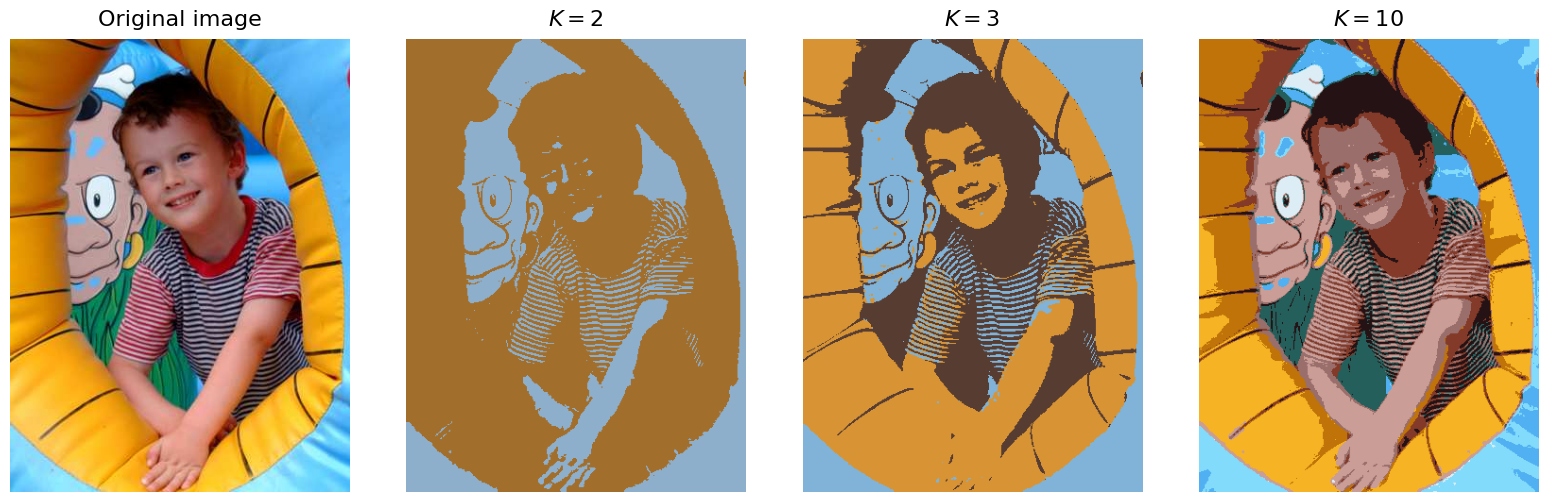

In [5]:
# 画像セグメンテーション実験と圧縮効率の評価
possible_img_paths = [
    Path('common/data/segmentation_source.png'),
    Path('../common/data/segmentation_source.png')
]
img_path = None
for p in possible_img_paths:
    if p.exists():
        img_path = p
        break

orig_img = Image.open(img_path).convert('RGB')
orig_arr = np.array(orig_img)

print(f"Source Image dimensions: {orig_arr.shape[1]}x{orig_arr.shape[0]} ({orig_arr.shape[0]*orig_arr.shape[1]:,} pixels)")

# K=2, 3, 10 でのセグメンテーション実行
for K_val in [2, 3, 10]:
    seg_img, palette, labels, info = image_segmentation_kmeans(orig_arr, K=K_val, random_state=42)
    print(f"\n--- K = {K_val} Segmentation ---")
    print(f"Palette (RGB):\n{palette}")
    print(f"Bits per pixel: {info['bits_per_pixel']} bit(s)")
    print(f"Original size:   {info['original_bits'] / 8 / 1024:.1f} KB")
    print(f"Compressed size: {info['compressed_bits'] / 8 / 1024:.1f} KB")
    print(f"Compression ratio: {info['compression_ratio']:.2f}x (Space savings: {info['space_savings_percent']:.1f}%)")

# Figure 15.3 の完全再現
fig_15_3 = generate_figure_15_3(save_path='result/fig_15_3_image_segmentation.png', show=True)


## 9. 第15.1節のまとめ

本節では、離散潜在変数を扱う最も基礎的なアルゴリズムである K-means クラスタリングを学びました：

1. **歪み尺度 $J$**: 各点と所属クラスタ中心とのユークリッド二乗誤差の総和。
2. **ロイドの交互最適化**:
   - **Eステップ**: 各点を最近傍の代表点に割り当てる（ボロノイ分割）。
   - **Mステップ**: 各代表点を割り当てられた点の重心に更新する。
   - $J$ は各ステップで単調非増加し、有限回の反復で局所解に収束する。
3. **逐次型 Robbins-Monro 更新**: ストリーミングデータに対する $O(1)$ オンライン学習。
4. **画像セグメンテーション**: RGB色空間におけるベクトル量子化と不可逆圧縮（24ビットから $\lceil \log_2 K \rceil$ ビットへの削減）。

次節（15.2節）では、K-means の決定論的・ハードな割当を確率的・ソフトな割当へと拡張した**混合ガウスモデル (Mixtures of Gaussians, GMM)** と、一般化された **EMアルゴリズム (Expectation–Maximization Algorithm)** について探求します。
